# Analisis del Caso: INNOVA-MEX's Bid for ENKONTROL
## Harvard Business School Case 9-812-008

---

**Que es este notebook?**  
Este es un documento interactivo donde puedes ejecutar codigo de Python celda por celda. Cada celda de codigo (las grises) se ejecuta presionando `Shift + Enter`. Las celdas con texto (como esta) son explicaciones.

**Como usarlo:**  
1. Ejecuta las celdas en orden, de arriba hacia abajo
2. Lee las explicaciones antes de cada celda de codigo
3. Los graficos y tablas aparecen automaticamente debajo de cada celda
4. Al final, copia los resultados y compartelos conmigo para interpretarlos juntos

---

### Resumen del Caso
Dos graduados de HBS (Eduardo Clave y Gustavo Fernandez de Loyola) crearon un **search fund** llamado INNOVA-MEX para comprar una empresa en Mexico. Encontraron **ENKONTROL**, el software ERP lider para la industria de construccion en Mexico. El caso analiza si deben cerrar el deal y a que precio.

## SECCION 1: Preparacion del Entorno

La siguiente celda importa las **librerias** (herramientas) que necesitamos:
- `pandas`: para manejar tablas de datos (como Excel pero en Python)
- `numpy`: para hacer calculos matematicos
- `matplotlib` y `seaborn`: para hacer graficos bonitos

**Solo ejecuta la celda con Shift+Enter y espera a que aparezca un numero entre corchetes [1].**

In [29]:
# ============================================================
# PASO 1: Importar librerias (herramientas que vamos a usar)
# ============================================================
# No te preocupes por estas lineas, solo son "preparativos"

import pandas as pd          # Para crear y manejar tablas
import numpy as np           # Para calculos matematicos
import matplotlib.pyplot as plt  # Para hacer graficos
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')  # Ocultar advertencias tecnicas

# Configuracion visual: hacer los graficos mas bonitos y grandes
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)    # Tamano de graficos
plt.rcParams['font.size'] = 12              # Tamano de letra
plt.rcParams['axes.titlesize'] = 14         # Tamano de titulos

print("Librerias cargadas correctamente! Puedes continuar.")

Librerias cargadas correctamente! Puedes continuar.


---
## SECCION 2: Datos Financieros de ENKONTROL

Aqui metemos los datos financieros del caso (Exhibit 4). Son los numeros reales de ENKONTROL (2008-2009) y las proyecciones (2010-2014).

**Que es cada cosa?**
- **Revenue (Ingresos)**: El dinero que entra por ventas
- **EBITDA**: Ganancia operativa antes de impuestos, depreciacion, etc. Es la mejor medida de "cuanto dinero genera el negocio"
- **EBITDA Margin**: Que porcentaje de los ingresos se convierte en ganancia (entre mas alto, mejor)

In [30]:
# ============================================================
# PASO 2: Crear la tabla con los datos financieros del caso
# ============================================================
# Estos datos vienen del Exhibit 4 del caso de Harvard

anos = [2008, 2009, '2010E', '2011E', '2012E', '2013E', '2014E']
# La "E" significa "Estimado" (proyeccion, no dato real)

# --- Desglose de Ingresos (% del total) ---
# Asi es como ENKONTROL gana dinero:
implementacion =   [22, 15, 14, 15, 15, 14, 14]   # Instalar el software en clientes nuevos
licencias =        [8,  6,  6,  6,  6,  6,  6]     # Vender la licencia del software
outsourcing =      [52, 58, 60, 58, 57, 57, 58]    # Consultoria post-implementacion (el fuerte!)
servicio_tecnico = [12, 12, 12, 12, 12, 12, 12]    # Soporte tecnico
mantenimiento =    [6,  8,  9,  9,  10, 10, 10]    # Cuota anual de mantenimiento (recurrente)

# --- Metricas Clave ---
revenue_growth =   [11.8, -24.3, 11.6, 10.1, 8.5, 10.0, 9.6]   # Crecimiento de ingresos (%)
ebitda_margin =    [23.6, 13.1, 12.7, 14.7, 16.2, 18.9, 21.2]   # Margen EBITDA (%)
ebiat_margin =     [15.2, 8.6,  8.3,  10.2, 11.2, 13.1, 14.7]   # Margen EBIAT (%)
nwc_nfa_rev =      [12.6, 21.8, 24.4, 18.6, 16.4, 16.6, 16.9]   # Capital de trabajo / Ingresos

# Crear tabla bonita con pandas
datos_financieros = pd.DataFrame({
    'Ano': anos,
    'Implementacion (%)': implementacion,
    'Licencias (%)': licencias,
    'Outsourcing (%)': outsourcing,
    'Servicio Tecnico (%)': servicio_tecnico,
    'Mantenimiento (%)': mantenimiento,
    'Crecimiento Ingresos (%)': revenue_growth,
    'Margen EBITDA (%)': ebitda_margin,
    'Margen EBIAT (%)': ebiat_margin,
    'Capital Trabajo/Ingresos (%)': nwc_nfa_rev
})

# Mostrar la tabla con formato
print("=" * 70)
print("   DATOS FINANCIEROS DE ENKONTROL (Exhibit 4)")
print("=" * 70)
datos_financieros.set_index('Ano')

   DATOS FINANCIEROS DE ENKONTROL (Exhibit 4)


,Implementacion (%),Licencias (%),Outsourcing (%),Servicio Tecnico (%),Mantenimiento (%),Crecimiento Ingresos (%),Margen EBITDA (%),Margen EBIAT (%),Capital Trabajo/Ingresos (%)
Ano,,,,,,,,,
2008,22,8,52,12,6,11.8,23.6,15.2,12.6
2009,15,6,58,12,8,-24.3,13.1,8.6,21.8
2010E,14,6,60,12,9,11.6,12.7,8.3,24.4
2011E,15,6,58,12,9,10.1,14.7,10.2,18.6
2012E,15,6,57,12,10,8.5,16.2,11.2,16.4
2013E,14,6,57,12,10,10.0,18.9,13.1,16.6
2014E,14,6,58,12,10,9.6,21.2,14.7,16.9


---
## SECCION 3: Visualizacion - Como gana dinero ENKONTROL?

El siguiente grafico muestra las **fuentes de ingreso** de ENKONTROL. Fijate como el **outsourcing (consultoria)** domina con ~58% de los ingresos. Esto es importante porque:
- La consultoria NO es escalable (vendes horas de personas)
- Las licencias de software SI son escalables (vendes copias sin costo adicional)
- El inversionista Craig Burr estaba preocupado exactamente por esto

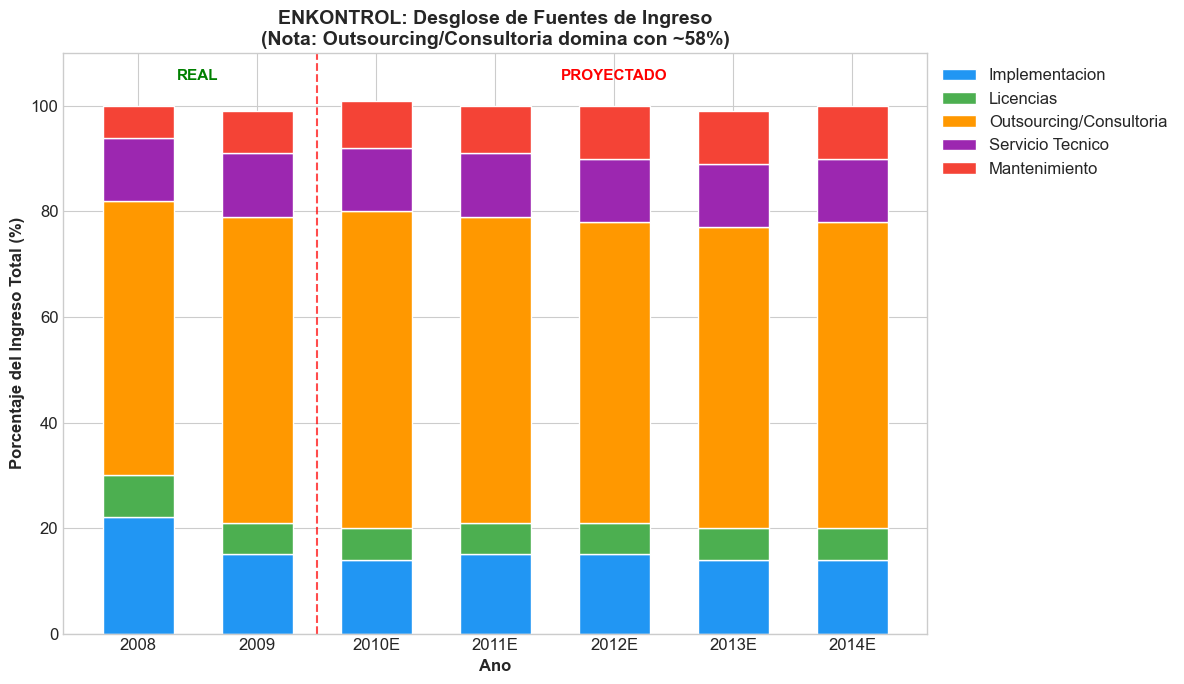


OBSERVACION CLAVE: El 85% de los ingresos viene de servicios
(consultoria + soporte + mantenimiento), NO del software en si.
Esto preocupaba a los inversionistas estadounidenses.


In [31]:
# ============================================================
# PASO 3: Grafico de barras apiladas - Fuentes de Ingreso
# ============================================================
# Este grafico muestra DE DONDE viene el dinero de ENKONTROL

fig, ax = plt.subplots(figsize=(12, 7))

anos_str = ['2008', '2009', '2010E', '2011E', '2012E', '2013E', '2014E']
x = np.arange(len(anos_str))
width = 0.6

# Colores profesionales para cada fuente de ingreso
colores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
labels = ['Implementacion', 'Licencias', 'Outsourcing/Consultoria', 
          'Servicio Tecnico', 'Mantenimiento']
datos = [implementacion, licencias, outsourcing, servicio_tecnico, mantenimiento]

# Apilar las barras una encima de otra
bottom = np.zeros(len(anos_str))
for i, (dato, color, label) in enumerate(zip(datos, colores, labels)):
    bars = ax.bar(x, dato, width, bottom=bottom, color=color, label=label, edgecolor='white')
    bottom += np.array(dato)

ax.set_xlabel('Ano', fontweight='bold')
ax.set_ylabel('Porcentaje del Ingreso Total (%)', fontweight='bold')
ax.set_title('ENKONTROL: Desglose de Fuentes de Ingreso\n(Nota: Outsourcing/Consultoria domina con ~58%)', 
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(anos_str)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylim(0, 110)

# Agregar linea de separacion para marcar datos reales vs proyectados
ax.axvline(x=1.5, color='red', linestyle='--', alpha=0.7)
ax.text(0.5, 105, 'REAL', ha='center', fontweight='bold', color='green', fontsize=11)
ax.text(4, 105, 'PROYECTADO', ha='center', fontweight='bold', color='red', fontsize=11)

plt.tight_layout()
plt.show()

print("\nOBSERVACION CLAVE: El 85% de los ingresos viene de servicios")
print("(consultoria + soporte + mantenimiento), NO del software en si.")
print("Esto preocupaba a los inversionistas estadounidenses.")

---
## SECCION 4: Evolucion de Rentabilidad (Margenes)

Este es uno de los graficos mas importantes. Muestra:
- **La caida brutal en 2009**: Los ingresos cayeron 24.3% y el margen EBITDA colapso de 23.6% a 13.1%
- **La recuperacion proyectada**: Se espera que los margenes vuelvan a ~21% para 2014
- **La pregunta clave**: Son realistas estas proyecciones? Pueden confiar en ellas para pagar lo que piden?

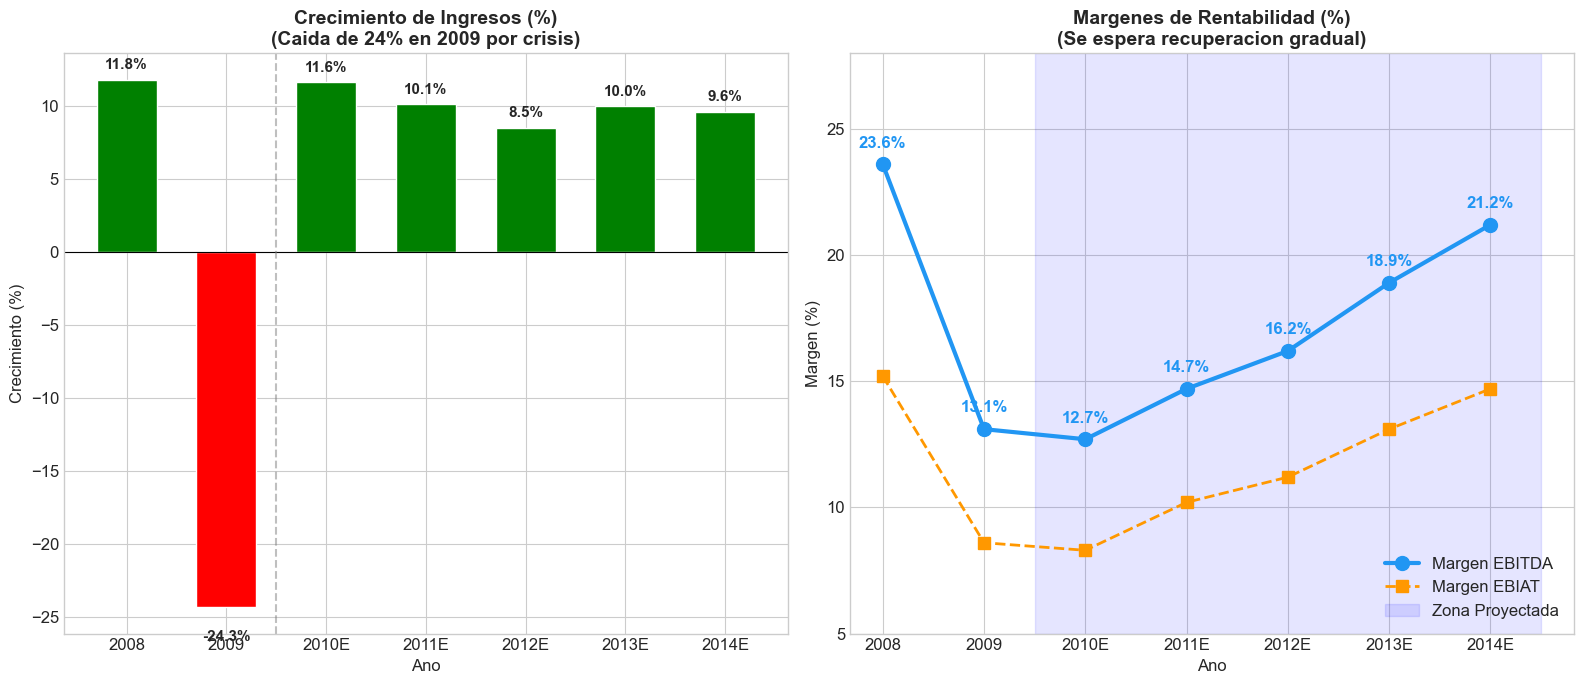

PUNTO IMPORTANTE: El margen EBITDA cayo a la mitad en 2009.
La empresa NO pudo recortar costos ('no se podia cortar ni un peso').
Esto significa que los costos son mayormente FIJOS (salarios de consultores).


In [32]:
# ============================================================
# PASO 4: Grafico de margenes y crecimiento
# ============================================================
# Dos graficos lado a lado para ver la salud financiera

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

anos_str = ['2008', '2009', '2010E', '2011E', '2012E', '2013E', '2014E']

# --- GRAFICO IZQUIERDO: Crecimiento de Ingresos ---
colores_barras = ['green' if x >= 0 else 'red' for x in revenue_growth]
bars = ax1.bar(anos_str, revenue_growth, color=colores_barras, edgecolor='white', width=0.6)

# Poner el valor encima de cada barra
for bar, val in zip(bars, revenue_growth):
    y_pos = bar.get_height() if val >= 0 else bar.get_height() - 3
    ax1.text(bar.get_x() + bar.get_width()/2, y_pos + 0.5, f'{val}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=1.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Crecimiento de Ingresos (%)\n(Caida de 24% en 2009 por crisis)', fontweight='bold')
ax1.set_ylabel('Crecimiento (%)')
ax1.set_xlabel('Ano')

# --- GRAFICO DERECHO: Margenes de Rentabilidad ---
ax2.plot(anos_str, ebitda_margin, 'o-', color='#2196F3', linewidth=3, 
         markersize=10, label='Margen EBITDA', zorder=5)
ax2.plot(anos_str, ebiat_margin, 's--', color='#FF9800', linewidth=2, 
         markersize=8, label='Margen EBIAT', zorder=5)

# Sombrear la zona de proyeccion
ax2.axvspan(1.5, 6.5, alpha=0.1, color='blue', label='Zona Proyectada')

# Valores sobre los puntos
for i, (ebitda, ebiat) in enumerate(zip(ebitda_margin, ebiat_margin)):
    ax2.annotate(f'{ebitda}%', (anos_str[i], ebitda), textcoords="offset points", 
                xytext=(0, 12), ha='center', fontweight='bold', color='#2196F3')

ax2.set_title('Margenes de Rentabilidad (%)\n(Se espera recuperacion gradual)', fontweight='bold')
ax2.set_ylabel('Margen (%)')
ax2.set_xlabel('Ano')
ax2.legend(loc='lower right')
ax2.set_ylim(5, 28)

plt.tight_layout()
plt.show()

print("PUNTO IMPORTANTE: El margen EBITDA cayo a la mitad en 2009.")
print("La empresa NO pudo recortar costos ('no se podia cortar ni un peso').")
print("Esto significa que los costos son mayormente FIJOS (salarios de consultores).")

---
## SECCION 5: Analisis de Valuacion - Cuanto vale ENKONTROL?

Ahora viene lo mas importante: **cuanto deberian pagar por ENKONTROL?**

Vamos a calcular la valuacion usando el metodo de **multiplos de EBITDA**, que es el que usa el caso:
- **Oferta original (Dic 2009)**: 5.0x EBITDA de 2009
- **Oferta revisada (Ene 2010)**: 5.68x EBITDA de 2009
- El banquero de ENKONTROL sugeria usar Oracle como comparable (9x+ EBITDA), lo cual es **absurdo** para una empresa de este tamano

Tambien haremos un analisis de **que pasaria si** cambiamos el multiplo.

   ANALISIS DE VALUACION POR MULTIPLOS DE EBITDA
   (Usando EBITDA 2009 estimado = $1.2M USD)
Multiplo         Escenario EV Total ($M) Costo 80% ($M)
    4.0x  Muy\nConservador        $4.80M         $3.84M
    4.5x       Conservador        $5.40M         $4.32M
    5.0x  Oferta\nOriginal        $6.00M         $4.80M
   5.68x  Oferta\nRevisada        $6.82M         $5.45M
    6.0x          Moderado        $7.20M         $5.76M
    7.0x          Agresivo        $8.40M         $6.72M
    8.0x     Muy\nAgresivo        $9.60M         $7.68M
    9.0x Oracle\n(Absurdo)       $10.80M         $8.64M


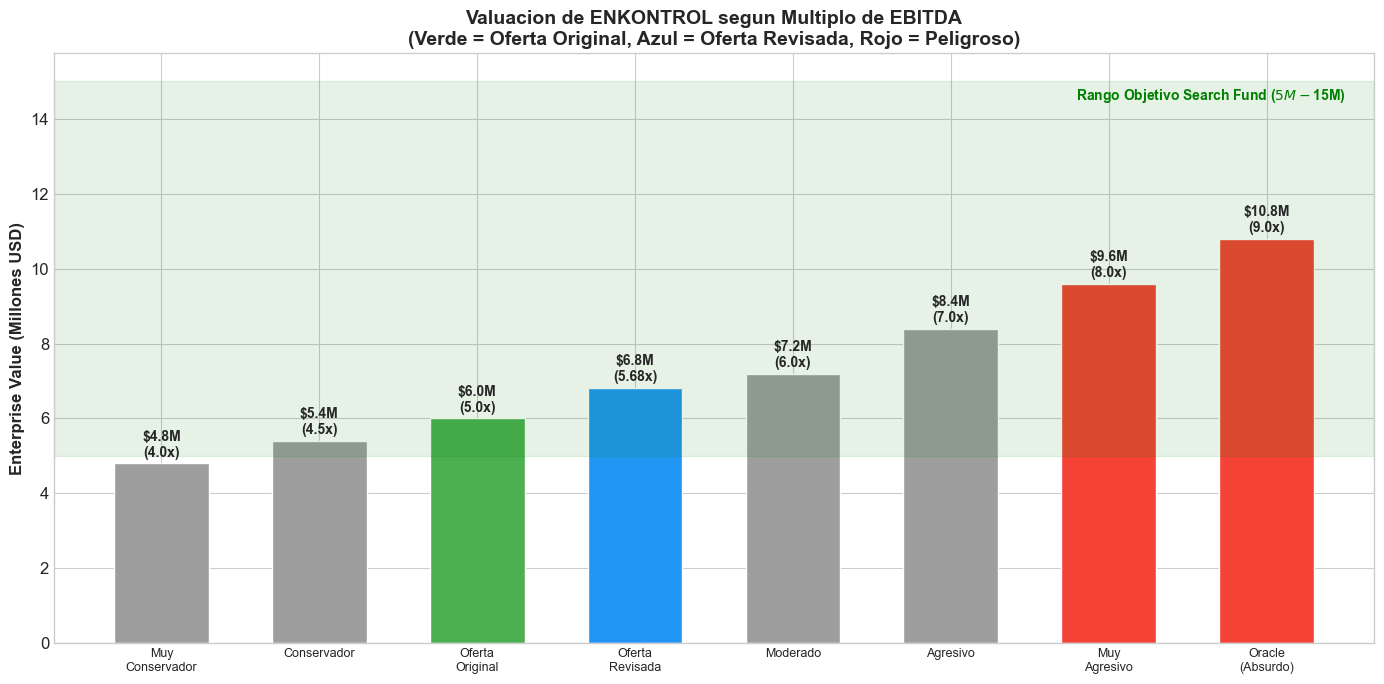

In [33]:
# ============================================================
# PASO 5: Analisis de Valuacion por Multiplos
# ============================================================
# El "multiplo" es como un factor: EBITDA x Multiplo = Valor de la Empresa
# 
# Ejemplo simple: Si tu empresa genera $1 millon de EBITDA y el multiplo 
# es 5x, la empresa "vale" $5 millones.
#
# El EBITDA de 2009 fue bajo por la crisis. Usaremos diferentes escenarios.

# Nota: No tenemos los numeros absolutos de ingresos del caso,
# pero sabemos que la empresa esta en el rango de $5M-$15M de Enterprise Value.
# Vamos a hacer el analisis con un EBITDA de 2009 normalizado.

# Basados en el caso: la oferta de 5x EBITDA 2009 y 5.68x EBITDA 2009
# El Enterprise Value objetivo esta entre $5M y $15M USD

# Supongamos un EBITDA 2009 de ~$1.2M USD (consistente con el rango del caso)
ebitda_2009 = 1.2  # millones USD (estimacion basada en el rango del caso)

# Diferentes multiplos para analizar
multiplos = [4.0, 4.5, 5.0, 5.68, 6.0, 7.0, 8.0, 9.0]
etiquetas = ['Muy\nConservador', 'Conservador', 'Oferta\nOriginal', 
             'Oferta\nRevisada', 'Moderado', 'Agresivo', 'Muy\nAgresivo', 
             'Oracle\n(Absurdo)']

# Calcular Enterprise Value para cada multiplo
ev_total = [ebitda_2009 * m for m in multiplos]
ev_80pct = [ev * 0.80 for ev in ev_total]  # INNOVA compra solo 80%

print("=" * 75)
print("   ANALISIS DE VALUACION POR MULTIPLOS DE EBITDA")
print(f"   (Usando EBITDA 2009 estimado = ${ebitda_2009}M USD)")
print("=" * 75)

valuacion_df = pd.DataFrame({
    'Multiplo': [f'{m}x' for m in multiplos],
    'Escenario': etiquetas,
    'EV Total ($M)': [f'${ev:.2f}M' for ev in ev_total],
    'Costo 80% ($M)': [f'${ev:.2f}M' for ev in ev_80pct],
})
print(valuacion_df.to_string(index=False))

# --- GRAFICO ---
fig, ax = plt.subplots(figsize=(14, 7))

colores_barras = []
for m in multiplos:
    if m == 5.0:
        colores_barras.append('#4CAF50')    # Verde = Oferta Original
    elif m == 5.68:
        colores_barras.append('#2196F3')    # Azul = Oferta Revisada
    elif m >= 8:
        colores_barras.append('#F44336')    # Rojo = Peligroso
    else:
        colores_barras.append('#9E9E9E')    # Gris = Otros

bars = ax.bar(range(len(multiplos)), ev_total, color=colores_barras, 
              edgecolor='white', width=0.6)

# Poner valores encima
for bar, ev, m in zip(bars, ev_total, multiplos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'${ev:.1f}M\n({m}x)', ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

ax.set_xticks(range(len(multiplos)))
ax.set_xticklabels(etiquetas, fontsize=9)
ax.set_ylabel('Enterprise Value (Millones USD)', fontweight='bold')
ax.set_title('Valuacion de ENKONTROL segun Multiplo de EBITDA\n'
             '(Verde = Oferta Original, Azul = Oferta Revisada, Rojo = Peligroso)', 
             fontweight='bold')

# Zona de rango objetivo del search fund ($5M - $15M)
ax.axhspan(5, 15, alpha=0.1, color='green')
ax.text(7.5, 14.5, 'Rango Objetivo Search Fund ($5M-$15M)', 
        ha='right', fontsize=10, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

---
## SECCION 6: Estructura del Deal - Como se financia la compra?

Esta es la parte mas tecnica pero tambien la mas interesante. Veamos como se divide el pastel:

**Que es cada fuente de financiamiento?**
- **Equity (Capital propio)**: Dinero que ponen los inversionistas de INNOVA. Es lo mas caro porque esperan el mayor retorno.
- **Deuda Subordinada**: Un prestamo de los inversionistas al 14% anual en USD. Se paga antes que el equity.
- **Seller Financing (Nota del vendedor)**: Salcedo acepta que le paguen parte del precio a plazos. Tasa = TIIE + 7% en pesos.

**Por que importa esto?**
En Mexico NO hay credito bancario para estas transacciones, asi que todo el peso cae en los inversionistas. En EUA tipicamente el 60-70% se financia con deuda bancaria barata.

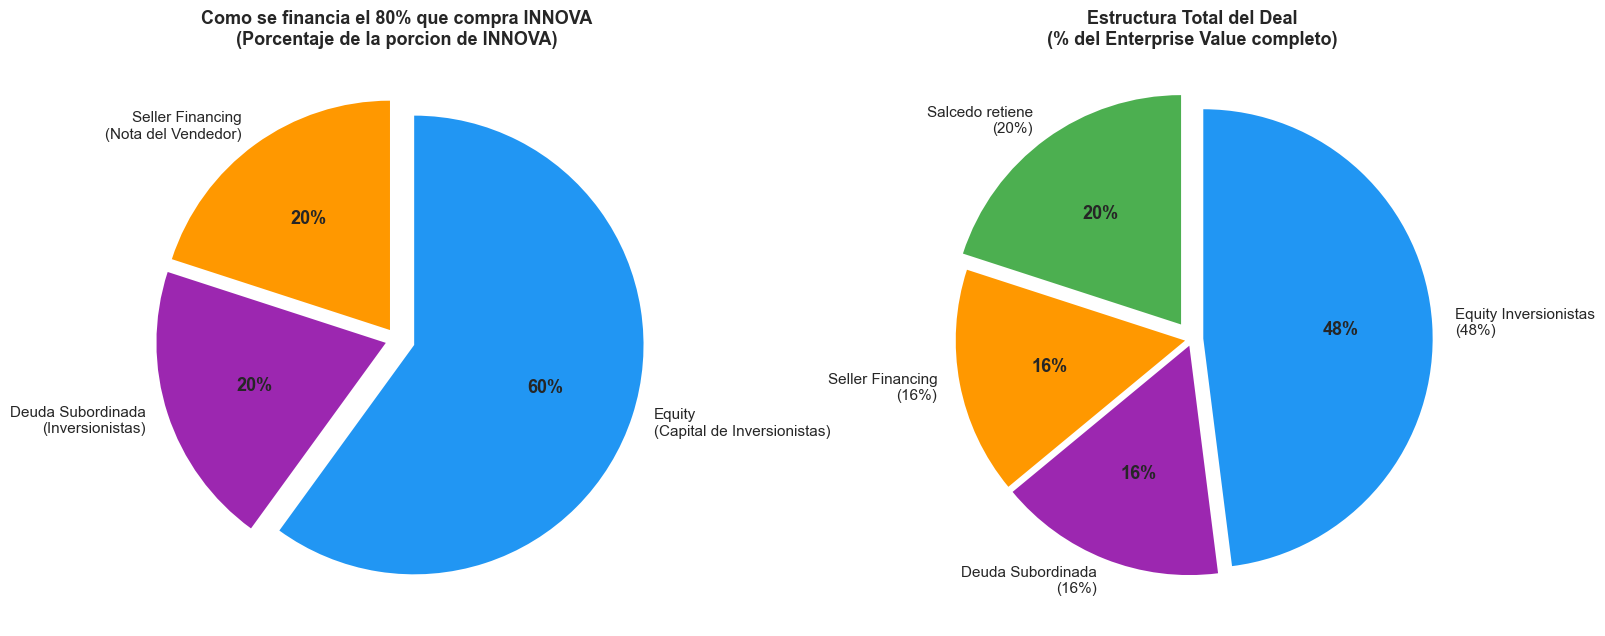

   CONDICIONES DE CADA FUENTE DE FINANCIAMIENTO

1. SELLER FINANCING (Nota del Vendedor):
   - Tasa: TIIE + 7% anual (en pesos mexicanos)
   - Pago: 10 pagos semestrales iguales
   - Ventaja: Salcedo tiene 'skin in the game'

2. DEUDA SUBORDINADA (de inversionistas):
   - Tasa: 14% anual (en dolares USD)
   - Pago: 10 pagos semestrales iguales
   - Nota: Los managers (Clave y Fernandez) cargan
     con el riesgo cambiario (peso vs dolar)

3. EQUITY (Capital de inversionistas):
   - Sin tasa fija, depende del desempeno
   - Meta: 30% de retorno anual compuesto (IRR)
   - Los managers reciben hasta 30% del equity


In [34]:
# ============================================================
# PASO 6: Estructura del Deal (Exhibit 5)
# ============================================================
# Veamos como se divide el financiamiento de la compra

# Estructura del deal (del Exhibit 5):
# INNOVA compra 80% de ENKONTROL. El otro 20% se queda con Salcedo.
# Del 80% que financia INNOVA:

estructura = {
    'Seller Financing\n(Nota del Vendedor)': 20,    # 20% del 80% = 16% del total
    'Deuda Subordinada\n(Inversionistas)': 20,       # 20% del 80% = 16% del total
    'Equity\n(Capital de Inversionistas)': 60         # 60% del 80% = 48% del total
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- GRAFICO IZQUIERDO: Pie chart de la porcion de INNOVA (80%) ---
colores_pie = ['#FF9800', '#9C27B0', '#2196F3']
explode = (0.05, 0.05, 0.08)

wedges, texts, autotexts = ax1.pie(
    estructura.values(), 
    labels=estructura.keys(),
    colors=colores_pie,
    explode=explode,
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

ax1.set_title('Como se financia el 80% que compra INNOVA\n(Porcentaje de la porcion de INNOVA)', 
              fontweight='bold', fontsize=13)

# --- GRAFICO DERECHO: Estructura total de propiedad ---
total_estructura = {
    'Salcedo retiene\n(20%)': 20,
    'Seller Financing\n(16%)': 16,
    'Deuda Subordinada\n(16%)': 16,
    'Equity Inversionistas\n(48%)': 48
}
colores_total = ['#4CAF50', '#FF9800', '#9C27B0', '#2196F3']

wedges2, texts2, autotexts2 = ax2.pie(
    total_estructura.values(),
    labels=total_estructura.keys(),
    colors=colores_total,
    explode=(0.08, 0.03, 0.03, 0.05),
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
for autotext in autotexts2:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

ax2.set_title('Estructura Total del Deal\n(% del Enterprise Value completo)', 
              fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# Detalles de las condiciones
print("=" * 65)
print("   CONDICIONES DE CADA FUENTE DE FINANCIAMIENTO")
print("=" * 65)
print()
print("1. SELLER FINANCING (Nota del Vendedor):")
print("   - Tasa: TIIE + 7% anual (en pesos mexicanos)")
print("   - Pago: 10 pagos semestrales iguales")
print("   - Ventaja: Salcedo tiene 'skin in the game'")
print()
print("2. DEUDA SUBORDINADA (de inversionistas):")
print("   - Tasa: 14% anual (en dolares USD)")
print("   - Pago: 10 pagos semestrales iguales")
print("   - Nota: Los managers (Clave y Fernandez) cargan")
print("     con el riesgo cambiario (peso vs dolar)")
print()
print("3. EQUITY (Capital de inversionistas):")
print("   - Sin tasa fija, depende del desempeno")
print("   - Meta: 30% de retorno anual compuesto (IRR)")
print("   - Los managers reciben hasta 30% del equity")

---
## SECCION 7: Analisis de Retorno (IRR) para Inversionistas

El **IRR (Internal Rate of Return)** es LA metrica que usan los inversionistas para decidir si vale la pena. Es basicamente "que porcentaje anual estoy ganando con mi dinero".

**Como funciona?**
- Pones dinero hoy (inversion inicial)
- Recibes pagos de deuda subordinada durante 5 anos
- Al final (ano 5) vendes la empresa a un multiplo de EBITDA
- El IRR calcula la tasa de retorno anual que iguala todo eso

Vamos a simular diferentes escenarios de salida (venta) para ver que IRR obtendrian los inversionistas.

In [35]:
# ============================================================
# PASO 7: Simulacion de Retornos (IRR) para Inversionistas
# ============================================================
# Vamos a modelar cuanto ganarian los inversionistas bajo
# diferentes escenarios de crecimiento y multiplo de salida.

# SUPUESTOS BASE (del caso):
ev_compra = ebitda_2009 * 5.68       # Enterprise Value a 5.68x EBITDA
porcion_innova = ev_compra * 0.80    # INNOVA compra 80%

# Fuentes de financiamiento del 80%:
seller_note = porcion_innova * 0.20      # 20% Seller Financing
deuda_sub = porcion_innova * 0.20        # 20% Deuda Subordinada  
equity_inv = porcion_innova * 0.60       # 60% Equity

print("=" * 60)
print("   ESTRUCTURA FINANCIERA DEL DEAL")
print("=" * 60)
print(f"   EBITDA 2009:              ${ebitda_2009:.2f}M")
print(f"   Multiplo:                 5.68x")
print(f"   Enterprise Value Total:   ${ev_compra:.2f}M")
print(f"   Porcion INNOVA (80%):     ${porcion_innova:.2f}M")
print(f"   --------------------------------")
print(f"   Seller Financing (20%):   ${seller_note:.2f}M")
print(f"   Deuda Subordinada (20%):  ${deuda_sub:.2f}M")
print(f"   Equity Invertido (60%):   ${equity_inv:.2f}M")
print()

# --- SIMULACION DE IRR ---
# Escenarios: diferentes tasas de crecimiento de EBITDA y multiplos de salida
tasas_crecimiento = [5, 8, 10, 15, 20]  # Crecimiento anual del EBITDA (%)
multiplos_salida = [4.0, 5.0, 5.68, 6.0, 7.0, 8.0]  # Multiplo al vender en ano 5
horizonte = 5  # Anos hasta la venta

# La deuda subordinada paga 14% anual en USD
tasa_deuda_sub = 0.14

print("=" * 60)
print("   TABLA DE IRR DEL INVERSIONISTA")
print("   (Segun crecimiento de EBITDA y multiplo de salida)")
print("=" * 60)
print()
print("Lectura: Cada celda muestra el IRR anual que obtendria")
print("el inversionista si el EBITDA crece X% anual y la empresa")
print("se vende a Y veces EBITDA en el ano 5.")
print()

# Crear matriz de IRR
irr_matrix = []

for crec in tasas_crecimiento:
    fila_irr = []
    for mult_sal in multiplos_salida:
        # EBITDA en ano 5
        ebitda_salida = ebitda_2009 * (1 + crec/100) ** horizonte
        
        # Enterprise Value al vender
        ev_salida = ebitda_salida * mult_sal
        
        # Valor del equity de INNOVA al vender (80% de EV, menos deuda restante)
        # Suponemos que la deuda ya se pago con flujos operativos
        valor_equity_innova = ev_salida * 0.80  # 80% le pertenece a INNOVA
        
        # Flujos del inversionista:
        # Ano 0: Invierte equity + deuda subordinada
        inversion_total = equity_inv + deuda_sub
        
        # Anos 1-5: Recibe intereses de deuda subordinada
        interes_anual = deuda_sub * tasa_deuda_sub
        
        # Ano 5: Recupera deuda subordinada + valor de su equity
        # Los managers tienen hasta 30% del equity de INNOVA
        # Pero solo si IRR > 15%, asi que simplificamos con 75% para inversionistas
        valor_equity_inv = valor_equity_innova * 0.70  # 70% para inversionistas
        pago_final = valor_equity_inv + deuda_sub  # Recupera deuda + equity
        
        # Flujos de caja del inversionista
        flujos = [-inversion_total]  # Ano 0: sale dinero
        for t in range(1, horizonte):
            flujos.append(interes_anual)  # Anos 1-4: intereses
        flujos.append(interes_anual + pago_final)  # Ano 5: intereses + venta
        
        # Calcular IRR con biseccion (sin necesidad de scipy ni np.irr)
        def calcular_irr(flujos):
            def npv(r):
                return sum(f / (1 + r) ** t for t, f in enumerate(flujos))
            try:
                low, high = -0.49, 5.0
                if npv(low) * npv(high) > 0:
                    return float('nan')
                for _ in range(200):
                    mid = (low + high) / 2.0
                    if abs(high - low) < 1e-8:
                        return mid * 100
                    if npv(mid) * npv(low) < 0:
                        high = mid
                    else:
                        low = mid
                return mid * 100
            except:
                return float('nan')
        irr = calcular_irr(flujos)
        
        fila_irr.append(irr)
    irr_matrix.append(fila_irr)

# Crear DataFrame con la matriz
irr_df = pd.DataFrame(
    irr_matrix,
    index=[f'{c}% crec.' for c in tasas_crecimiento],
    columns=[f'{m}x salida' for m in multiplos_salida]
)

# Formatear como porcentajes
irr_display = irr_df.map(lambda x: f'{x:.1f}%' if not np.isnan(x) else 'N/A')
print(irr_display)
print()
print("META DEL CASO: 30% IRR anual compuesto")
print("Celdas con >30% = el deal funciona para inversionistas")

   ESTRUCTURA FINANCIERA DEL DEAL
   EBITDA 2009:              $1.20M
   Multiplo:                 5.68x
   Enterprise Value Total:   $6.82M
   Porcion INNOVA (80%):     $5.45M
   --------------------------------
   Seller Financing (20%):   $1.09M
   Deuda Subordinada (20%):  $1.09M
   Equity Invertido (60%):   $3.27M

   TABLA DE IRR DEL INVERSIONISTA
   (Segun crecimiento de EBITDA y multiplo de salida)

Lectura: Cada celda muestra el IRR anual que obtendria
el inversionista si el EBITDA crece X% anual y la empresa
se vende a Y veces EBITDA en el ano 5.

          4.0x salida 5.0x salida 5.68x salida 6.0x salida 7.0x salida  \
5% crec.         4.2%        7.5%         9.6%       10.5%       13.1%   
8% crec.         6.2%        9.8%        11.9%       12.9%       15.7%   
10% crec.        7.7%       11.3%        13.6%       14.6%       17.4%   
15% crec.       11.3%       15.3%        17.7%       18.8%       21.9%   
20% crec.       15.1%       19.4%        22.0%       23.1%       2

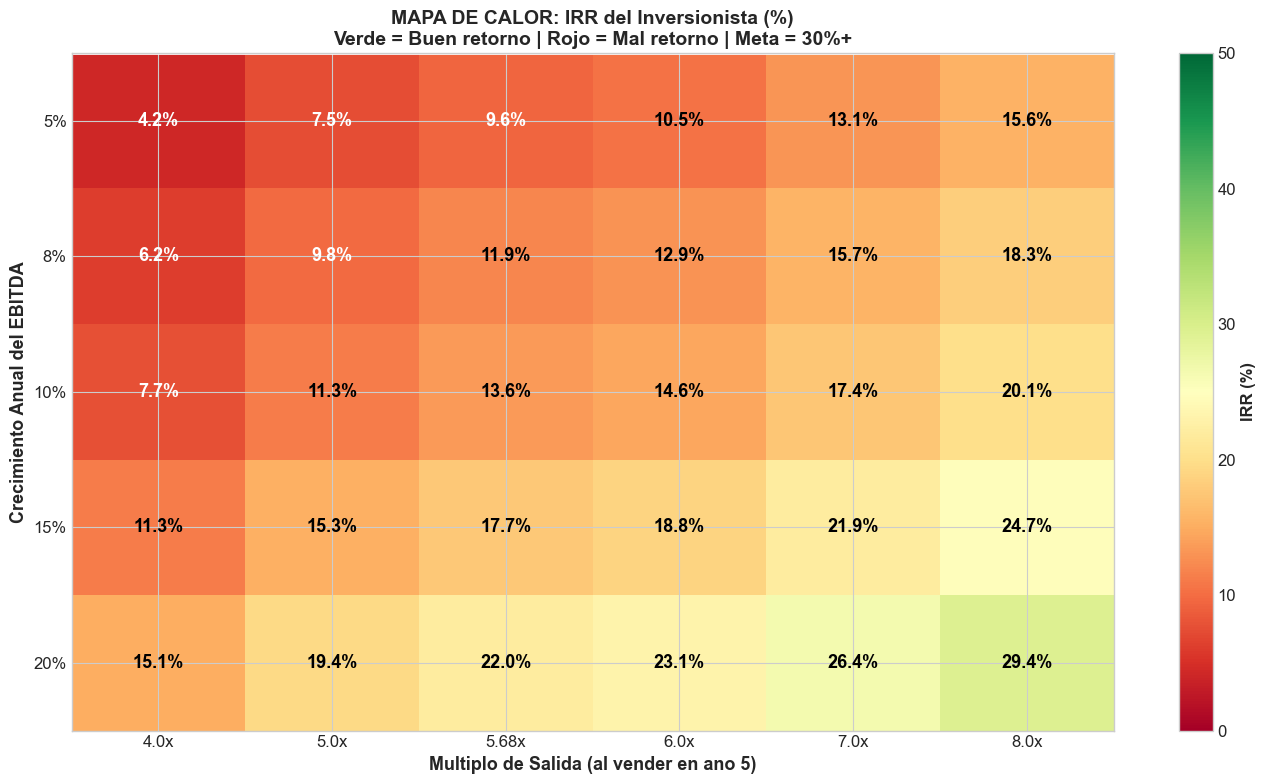


INTERPRETACION:
- Para lograr 30% IRR, necesitan crecimiento >10% Y multiplo de salida >5x
- Si el EBITDA crece solo 5% anual, NUNCA llegan a 30% IRR
- El crecimiento es CLAVE en este deal (como dijo el inversionista Alvarez)


In [36]:
# ============================================================
# PASO 7b: Mapa de Calor (Heatmap) de IRR
# ============================================================
# Un heatmap es como un mapa donde los colores indican valores:
# - VERDE OSCURO = excelente retorno (>30%)
# - AMARILLO = retorno moderado (15-30%)  
# - ROJO = mal retorno (<15%)

fig, ax = plt.subplots(figsize=(14, 8))

# Crear el heatmap
im = ax.imshow(irr_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=50)

# Poner los valores en cada celda
for i in range(len(tasas_crecimiento)):
    for j in range(len(multiplos_salida)):
        valor = irr_df.values[i, j]
        color_texto = 'white' if valor < 10 or valor > 45 else 'black'
        ax.text(j, i, f'{valor:.1f}%', ha='center', va='center',
                fontweight='bold', fontsize=13, color=color_texto)

# Etiquetas
ax.set_xticks(range(len(multiplos_salida)))
ax.set_xticklabels([f'{m}x' for m in multiplos_salida], fontsize=12)
ax.set_yticks(range(len(tasas_crecimiento)))
ax.set_yticklabels([f'{c}%' for c in tasas_crecimiento], fontsize=12)

ax.set_xlabel('Multiplo de Salida (al vender en ano 5)', fontweight='bold', fontsize=13)
ax.set_ylabel('Crecimiento Anual del EBITDA', fontweight='bold', fontsize=13)
ax.set_title('MAPA DE CALOR: IRR del Inversionista (%)\n'
             'Verde = Buen retorno | Rojo = Mal retorno | Meta = 30%+',
             fontweight='bold', fontsize=14)

# Barra de color
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('IRR (%)', fontweight='bold')

# Linea de referencia en 30%
ax.axhline(y=-0.5, color='white', linewidth=2)

plt.tight_layout()
plt.show()

print("\nINTERPRETACION:")
print("- Para lograr 30% IRR, necesitan crecimiento >10% Y multiplo de salida >5x")
print("- Si el EBITDA crece solo 5% anual, NUNCA llegan a 30% IRR")
print("- El crecimiento es CLAVE en este deal (como dijo el inversionista Alvarez)")

---
## SECCION 8: Analisis de Sensibilidad - Que pasa si las cosas salen mal?

En el mundo real, las cosas nunca salen exactamente como las planeas. Veamos que pasa con el retorno si:
1. **El peso se devalua** (recuerda que los inversionistas quieren retornos en dolares)
2. **El crecimiento es menor al esperado**
3. **El margen EBITDA no se recupera**

Este tipo de analisis se llama **"stress test"** - es como preguntarse "que tan mal pueden ir las cosas antes de que pierda dinero?"

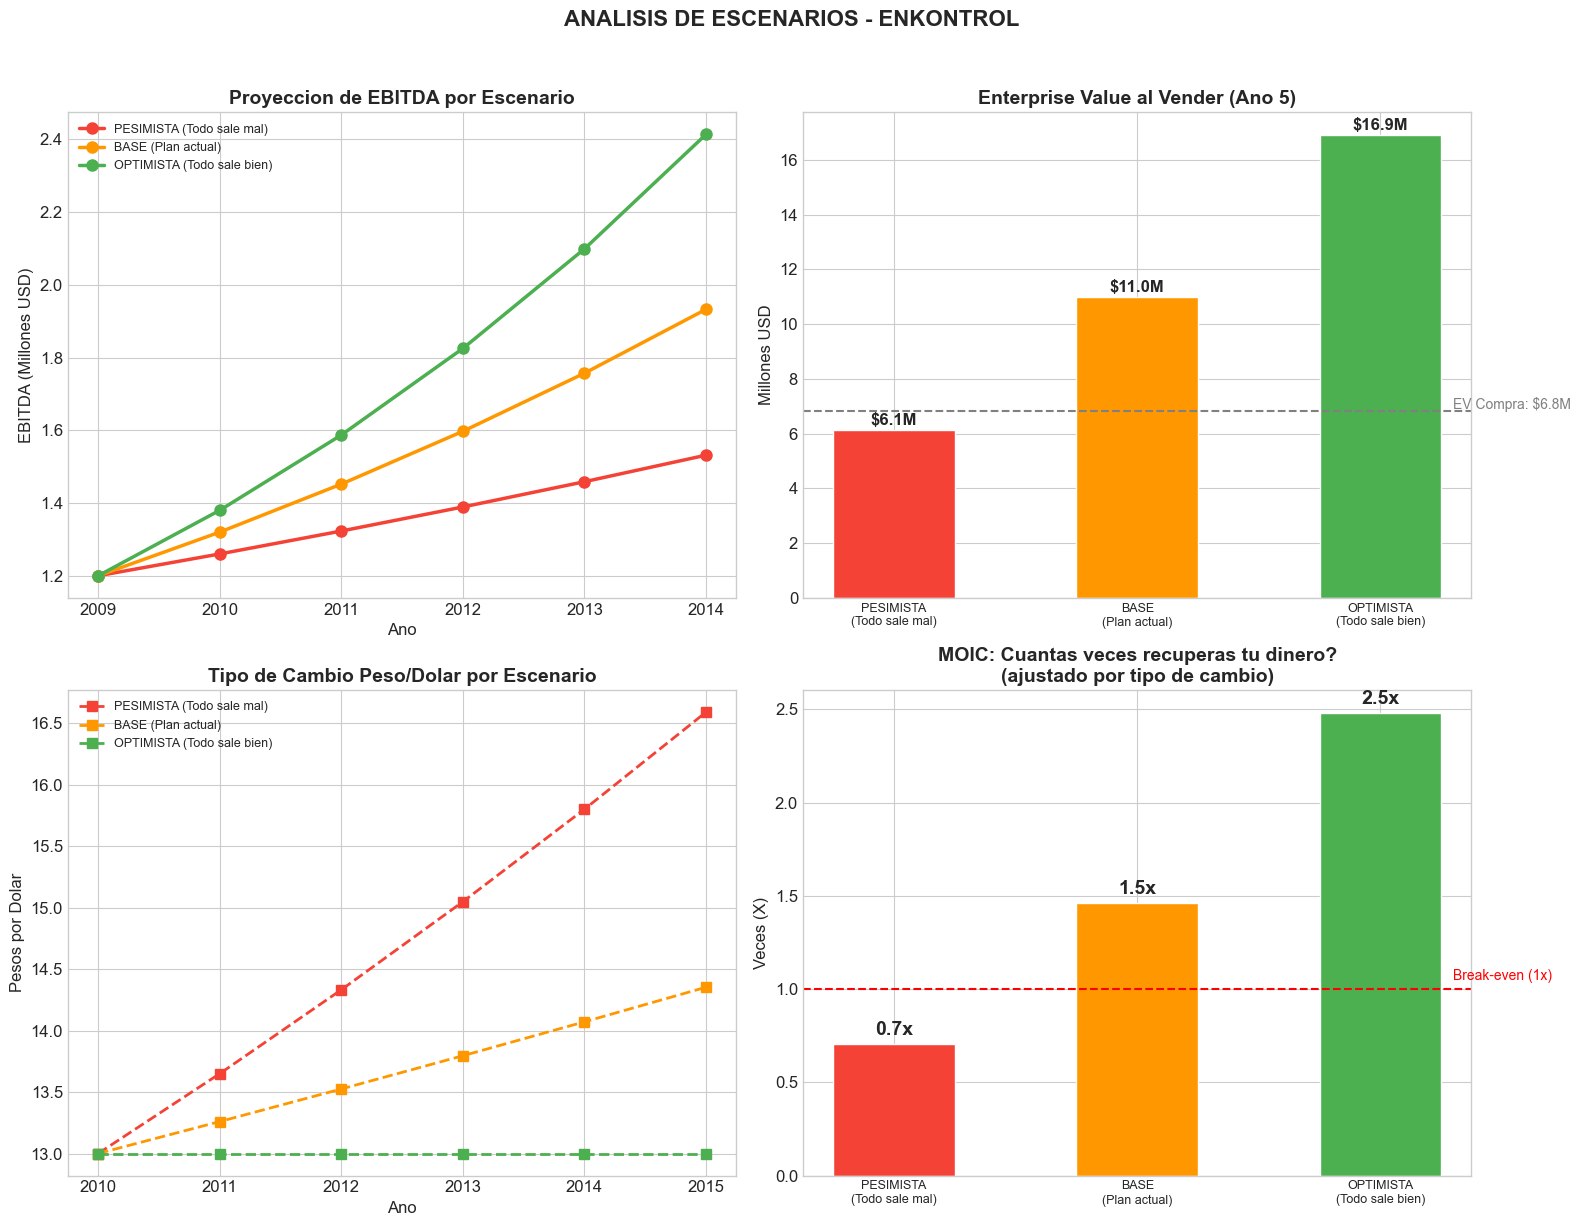


MOIC = Multiple on Invested Capital (Cuantas veces recuperas tu dinero)
  - <1x = Perdiste dinero
  - 1x = Solo recuperaste lo que invertiste
  - 2x = Duplicaste tu dinero
  - 3x+ = Excelente inversion


In [37]:
# ============================================================
# PASO 8: Analisis de Sensibilidad - Escenarios
# ============================================================
# Comparamos 3 escenarios: Pesimista, Base, y Optimista

escenarios = {
    'PESIMISTA\n(Todo sale mal)': {
        'crec_ingresos': 5,       # Crecimiento lento
        'margen_ebitda_final': 14, # Margenes no se recuperan
        'multiplo_salida': 4.0,   # Venta a multiplo bajo
        'devaluacion_anual': 5,   # Peso se devalua 5% anual vs USD
        'color': '#F44336'
    },
    'BASE\n(Plan actual)': {
        'crec_ingresos': 10,
        'margen_ebitda_final': 21,
        'multiplo_salida': 5.68,
        'devaluacion_anual': 2,
        'color': '#FF9800'
    },
    'OPTIMISTA\n(Todo sale bien)': {
        'crec_ingresos': 15,
        'margen_ebitda_final': 25,
        'multiplo_salida': 7.0,
        'devaluacion_anual': 0,
        'color': '#4CAF50'
    }
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Grafico 1: Crecimiento de EBITDA por escenario ---
ax = axes[0, 0]
for nombre, params in escenarios.items():
    ebitdas = [ebitda_2009]
    for t in range(1, 6):
        ebitdas.append(ebitdas[-1] * (1 + params['crec_ingresos']/100))
    ax.plot(range(6), ebitdas, 'o-', color=params['color'], linewidth=2.5, 
            markersize=8, label=nombre.replace('\n', ' '))
ax.set_title('Proyeccion de EBITDA por Escenario', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('EBITDA (Millones USD)')
ax.legend(fontsize=9)
ax.set_xticks(range(6))
ax.set_xticklabels(['2009', '2010', '2011', '2012', '2013', '2014'])

# --- Grafico 2: Enterprise Value al vender ---
ax = axes[0, 1]
ev_salidas = []
nombres_esc = []
colores_esc = []
for nombre, params in escenarios.items():
    ebitda_final = ebitda_2009 * (1 + params['crec_ingresos']/100) ** 5
    ev_sal = ebitda_final * params['multiplo_salida']
    ev_salidas.append(ev_sal)
    nombres_esc.append(nombre)
    colores_esc.append(params['color'])

bars = ax.bar(range(3), ev_salidas, color=colores_esc, edgecolor='white', width=0.5)
for bar, ev in zip(bars, ev_salidas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'${ev:.1f}M', ha='center', fontweight='bold', fontsize=12)

# Linea de referencia: EV de compra
ax.axhline(y=ev_compra, color='gray', linestyle='--', linewidth=1.5)
ax.text(2.3, ev_compra + 0.1, f'EV Compra: ${ev_compra:.1f}M', fontsize=10, color='gray')

ax.set_xticks(range(3))
ax.set_xticklabels(nombres_esc, fontsize=9)
ax.set_title('Enterprise Value al Vender (Ano 5)', fontweight='bold')
ax.set_ylabel('Millones USD')

# --- Grafico 3: Impacto del tipo de cambio ---
ax = axes[1, 0]
tc_2010 = 13.0  # Tipo de cambio peso/dolar en 2010 (aprox)
for nombre, params in escenarios.items():
    tcs = [tc_2010]
    for t in range(1, 6):
        tcs.append(tcs[-1] * (1 + params['devaluacion_anual']/100))
    ax.plot(range(6), tcs, 's--', color=params['color'], linewidth=2, 
            markersize=7, label=nombre.replace('\n', ' '))
ax.set_title('Tipo de Cambio Peso/Dolar por Escenario', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Pesos por Dolar')
ax.legend(fontsize=9)
ax.set_xticks(range(6))
ax.set_xticklabels(['2010', '2011', '2012', '2013', '2014', '2015'])

# --- Grafico 4: Retorno Multiplo del Dinero (MOIC) ---
ax = axes[1, 1]
moics = []
for nombre, params in escenarios.items():
    ebitda_final = ebitda_2009 * (1 + params['crec_ingresos']/100) ** 5
    ev_sal = ebitda_final * params['multiplo_salida']
    # Valor del equity de INNOVA al vender
    valor_innova = ev_sal * 0.80
    # Ajuste por tipo de cambio (ingresos en pesos, retornos en dolares)
    factor_fx = 1 / (1 + params['devaluacion_anual']/100) ** 5
    valor_en_usd = valor_innova * factor_fx
    # MOIC = cuantas veces recuperas tu inversion
    moic = valor_en_usd / porcion_innova
    moics.append(moic)

bars = ax.bar(range(3), moics, color=colores_esc, edgecolor='white', width=0.5)
for bar, moic in zip(bars, moics):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{moic:.1f}x', ha='center', fontweight='bold', fontsize=14)

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5)
ax.text(2.3, 1.05, 'Break-even (1x)', fontsize=10, color='red')
ax.set_xticks(range(3))
ax.set_xticklabels(nombres_esc, fontsize=9)
ax.set_title('MOIC: Cuantas veces recuperas tu dinero?\n(ajustado por tipo de cambio)', 
             fontweight='bold')
ax.set_ylabel('Veces (X)')

plt.suptitle('ANALISIS DE ESCENARIOS - ENKONTROL', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\nMOIC = Multiple on Invested Capital (Cuantas veces recuperas tu dinero)")
print("  - <1x = Perdiste dinero")
print("  - 1x = Solo recuperaste lo que invertiste")  
print("  - 2x = Duplicaste tu dinero")
print("  - 3x+ = Excelente inversion")

---
## SECCION 9: Comparacion Mexico vs EUA - Search Funds

Una de las cosas mas interesantes del caso es como el modelo de search fund cambia al aplicarse en Mexico. Veamos las diferencias clave visualmente.

   COMPARACION: SEARCH FUND TIPICO (EUA) vs INNOVA-MEX (MEXICO)
                        Metrica Search Fund Tipico (EUA) INNOVA-MEX (Mexico)
     Capital levantado (search)                 $350,000            $525,000
       Numero de inversionistas                       12                  15
         Meses buscando empresa                8.5 meses            ~7 meses
Ingresos de la empresa objetivo                    $7.1M                 N/D
  EBITDA de la empresa objetivo                    $1.0M              ~$1.2M
               Precio de compra                    $5.4M              ~$6.8M
     Deuda bancaria disponible?     SI (~63% del precio)             NO (0%)
         Equity de managers (%)                Hasta 25%           Hasta 30%
         IRR promedio historico                      33%           Meta: 30%
          IRR mediana historica                   -23.7%       N/A (primero)


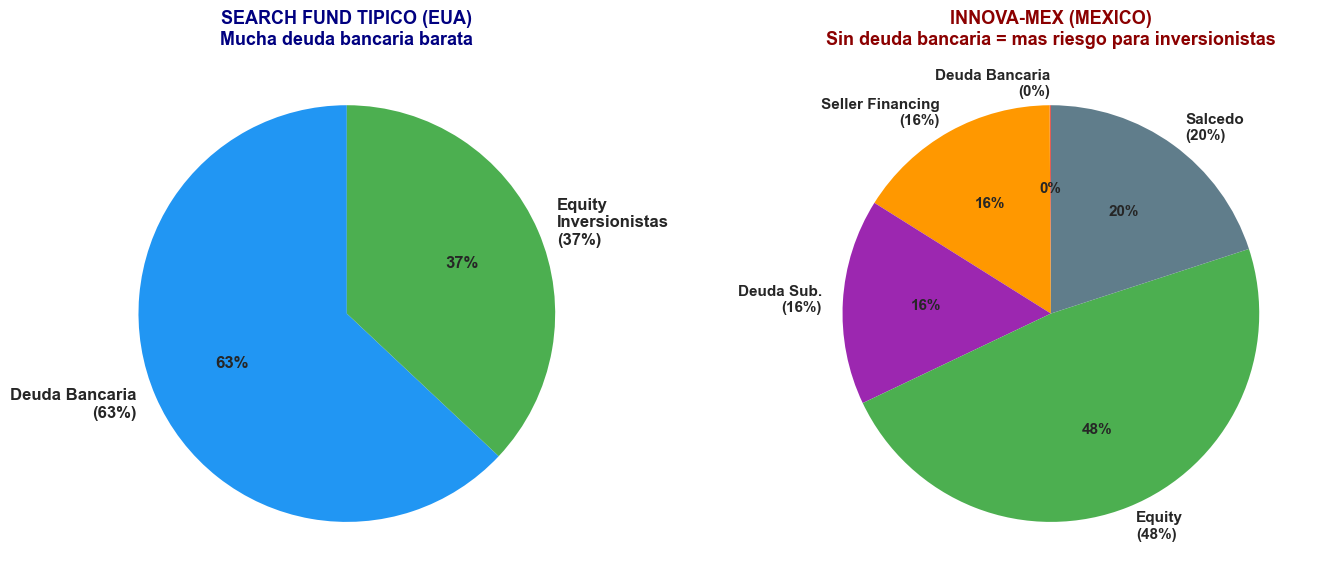


DIFERENCIA CRITICA:
En EUA, los bancos financian ~63% del deal con deuda barata.
En Mexico, NO HAY deuda bancaria. Los inversionistas ponen TODO.
Esto significa que el crecimiento tiene que compensar la falta de apalancamiento.


In [38]:
# ============================================================
# PASO 9: Comparacion Search Fund USA vs Mexico
# ============================================================
# Datos del Appendix A (Stanford Survey) vs INNOVA-MEX

comparacion = {
    'Metrica': [
        'Capital levantado (search)',
        'Numero de inversionistas',
        'Meses buscando empresa',
        'Ingresos de la empresa objetivo',
        'EBITDA de la empresa objetivo',
        'Precio de compra',
        'Deuda bancaria disponible?',
        'Equity de managers (%)',
        'IRR promedio historico',
        'IRR mediana historica'
    ],
    'Search Fund Tipico (EUA)': [
        '$350,000', '12', '8.5 meses', '$7.1M', '$1.0M',
        '$5.4M', 'SI (~63% del precio)', 'Hasta 25%', '33%', '-23.7%'
    ],
    'INNOVA-MEX (Mexico)': [
        '$525,000', '15', '~7 meses', 'N/D', f'~${ebitda_2009}M',
        f'~${ev_compra:.1f}M', 'NO (0%)', 'Hasta 30%', 'Meta: 30%', 'N/A (primero)'
    ]
}

df_comp = pd.DataFrame(comparacion)
print("=" * 80)
print("   COMPARACION: SEARCH FUND TIPICO (EUA) vs INNOVA-MEX (MEXICO)")
print("=" * 80)
print(df_comp.to_string(index=False))

# --- GRAFICO: Estructura de financiamiento USA vs Mexico ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# USA Tipico
usa_labels = ['Deuda Bancaria\n(63%)', 'Equity\nInversionistas\n(37%)']
usa_sizes = [63, 37]
usa_colors = ['#2196F3', '#4CAF50']
ax1.pie(usa_sizes, labels=usa_labels, colors=usa_colors, autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('SEARCH FUND TIPICO (EUA)\nMucha deuda bancaria barata', 
              fontweight='bold', fontsize=13, color='navy')

# Mexico (INNOVA-MEX)
mex_labels = ['Deuda Bancaria\n(0%)', 'Seller Financing\n(16%)', 
              'Deuda Sub.\n(16%)', 'Equity\n(48%)', 'Salcedo\n(20%)']
mex_sizes = [0.1, 16, 16, 48, 20]  # 0.1 para que aparezca la etiqueta
mex_colors = ['#F44336', '#FF9800', '#9C27B0', '#4CAF50', '#607D8B']
wedges, texts, autotexts = ax2.pie(mex_sizes, labels=mex_labels, colors=mex_colors, 
        autopct='%1.0f%%', startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('INNOVA-MEX (MEXICO)\nSin deuda bancaria = mas riesgo para inversionistas', 
              fontweight='bold', fontsize=13, color='darkred')

plt.tight_layout()
plt.show()

print("\nDIFERENCIA CRITICA:")
print("En EUA, los bancos financian ~63% del deal con deuda barata.")
print("En Mexico, NO HAY deuda bancaria. Los inversionistas ponen TODO.")
print("Esto significa que el crecimiento tiene que compensar la falta de apalancamiento.")

---
## SECCION 10: Equity de los Managers - El esquema de incentivos

Eduardo y Gustavo (los managers) reciben **hasta 30% del equity** de las acciones adquiridas, pero no todo de golpe. Hay un esquema de **vesting** (se van ganando las acciones con el tiempo y desempeno):

- **10%** al cerrar el deal (inmediato)
- **10%** se va ganando durante 4 anos (2.5% por ano)
- **10%** se gana solo si el IRR del inversionista supera ciertos "hurdles" (metas)

Esto alinea los intereses: los managers ganan MAS solo si los inversionistas ganan BIEN.

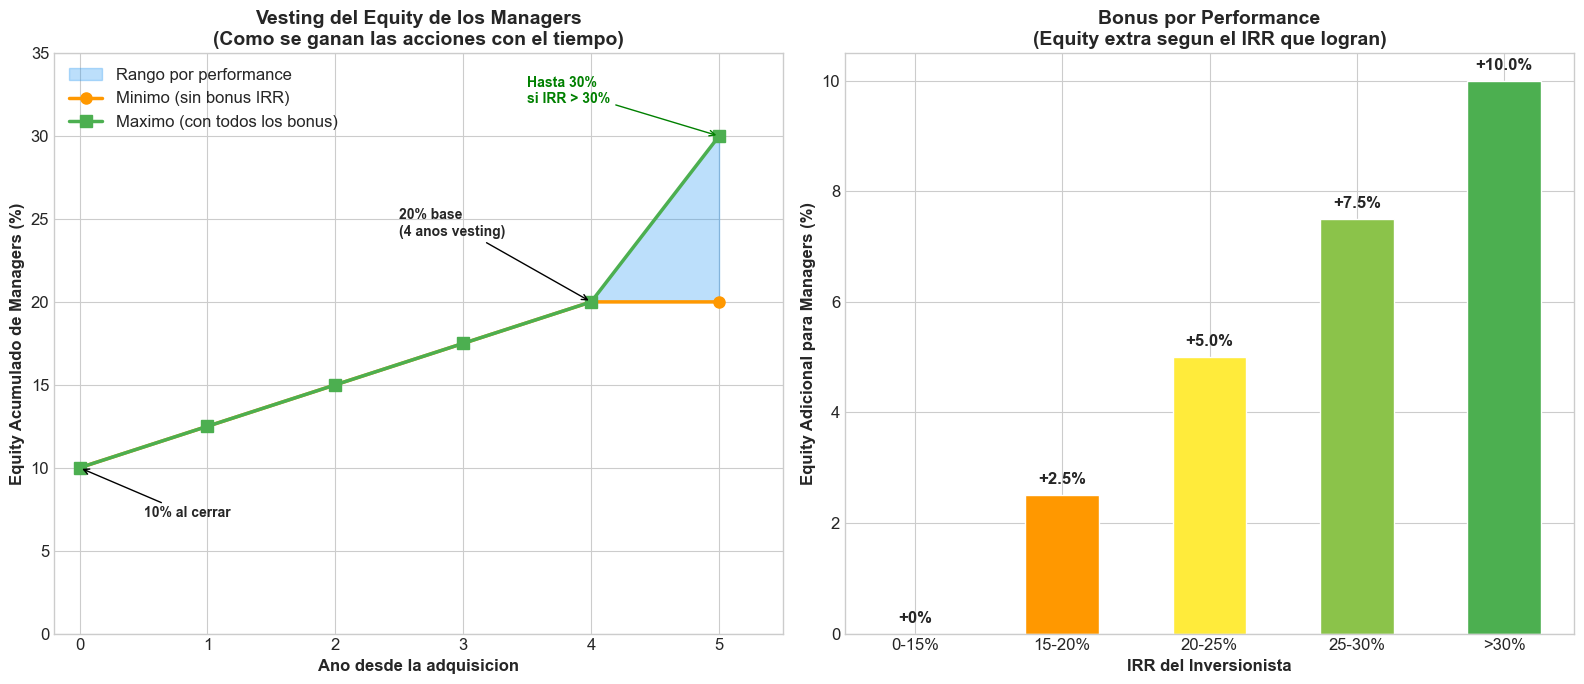

ALINEACION DE INCENTIVOS:
- Si el IRR es <15%, los managers NO reciben bonus (solo su 20% base)
- Si el IRR es >30%, los managers reciben el maximo de 30% total
- Esto motiva a Eduardo y Gustavo a maximizar el valor de la empresa


In [39]:
# ============================================================
# PASO 10: Esquema de Incentivos de los Managers
# ============================================================
# Cuanto equity reciben Eduardo y Gustavo segun el desempeno?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- GRAFICO 1: Vesting del equity (como se ganan las acciones) ---
anos_vesting = [0, 1, 2, 3, 4, 5]
# Tranche 1: 10% inmediato
# Tranche 2: 2.5% por ano durante 4 anos
# Tranche 3: depende del IRR (asumimos que se logra gradualmente)

equity_acumulado_min = [10, 12.5, 15, 17.5, 20, 20]  # Sin bonus por IRR
equity_acumulado_max = [10, 12.5, 15, 17.5, 20, 30]  # Con todos los bonuses

ax1.fill_between(anos_vesting, equity_acumulado_min, equity_acumulado_max, 
                 alpha=0.3, color='#2196F3', label='Rango por performance')
ax1.plot(anos_vesting, equity_acumulado_min, 'o-', color='#FF9800', linewidth=2.5,
         markersize=8, label='Minimo (sin bonus IRR)')
ax1.plot(anos_vesting, equity_acumulado_max, 's-', color='#4CAF50', linewidth=2.5,
         markersize=8, label='Maximo (con todos los bonus)')

# Anotaciones
ax1.annotate('10% al cerrar', xy=(0, 10), xytext=(0.5, 7),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold')
ax1.annotate('20% base\n(4 anos vesting)', xy=(4, 20), xytext=(2.5, 24),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold')
ax1.annotate('Hasta 30%\nsi IRR > 30%', xy=(5, 30), xytext=(3.5, 32),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, fontweight='bold', color='green')

ax1.set_xlabel('Ano desde la adquisicion', fontweight='bold')
ax1.set_ylabel('Equity Acumulado de Managers (%)', fontweight='bold')
ax1.set_title('Vesting del Equity de los Managers\n(Como se ganan las acciones con el tiempo)', 
              fontweight='bold')
ax1.legend(loc='upper left')
ax1.set_ylim(0, 35)
ax1.set_xlim(-0.2, 5.5)

# --- GRAFICO 2: Performance Hurdles (metas de IRR) ---
irr_hurdles = ['0-15%', '15-20%', '20-25%', '25-30%', '>30%']
bonus_pct = [0, 25, 25, 25, 25]  # % del tranche 3 que se desbloquea
bonus_acum = [0, 2.5, 5.0, 7.5, 10.0]  # Equity adicional acumulado

colores_h = ['#F44336', '#FF9800', '#FFEB3B', '#8BC34A', '#4CAF50']
bars = ax2.bar(irr_hurdles, bonus_acum, color=colores_h, edgecolor='white', width=0.5)

for bar, val in zip(bars, bonus_acum):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'+{val}%', ha='center', fontweight='bold', fontsize=12)

ax2.set_xlabel('IRR del Inversionista', fontweight='bold')
ax2.set_ylabel('Equity Adicional para Managers (%)', fontweight='bold')
ax2.set_title('Bonus por Performance\n(Equity extra segun el IRR que logran)', fontweight='bold')

plt.tight_layout()
plt.show()

print("ALINEACION DE INCENTIVOS:")
print("- Si el IRR es <15%, los managers NO reciben bonus (solo su 20% base)")
print("- Si el IRR es >30%, los managers reciben el maximo de 30% total")
print("- Esto motiva a Eduardo y Gustavo a maximizar el valor de la empresa")

---
## SECCION 11: Analisis FODA (SWOT) y Riesgos Clave

Vamos a hacer un analisis visual de las **Fortalezas, Oportunidades, Debilidades y Amenazas** del deal, basado en la informacion del caso.

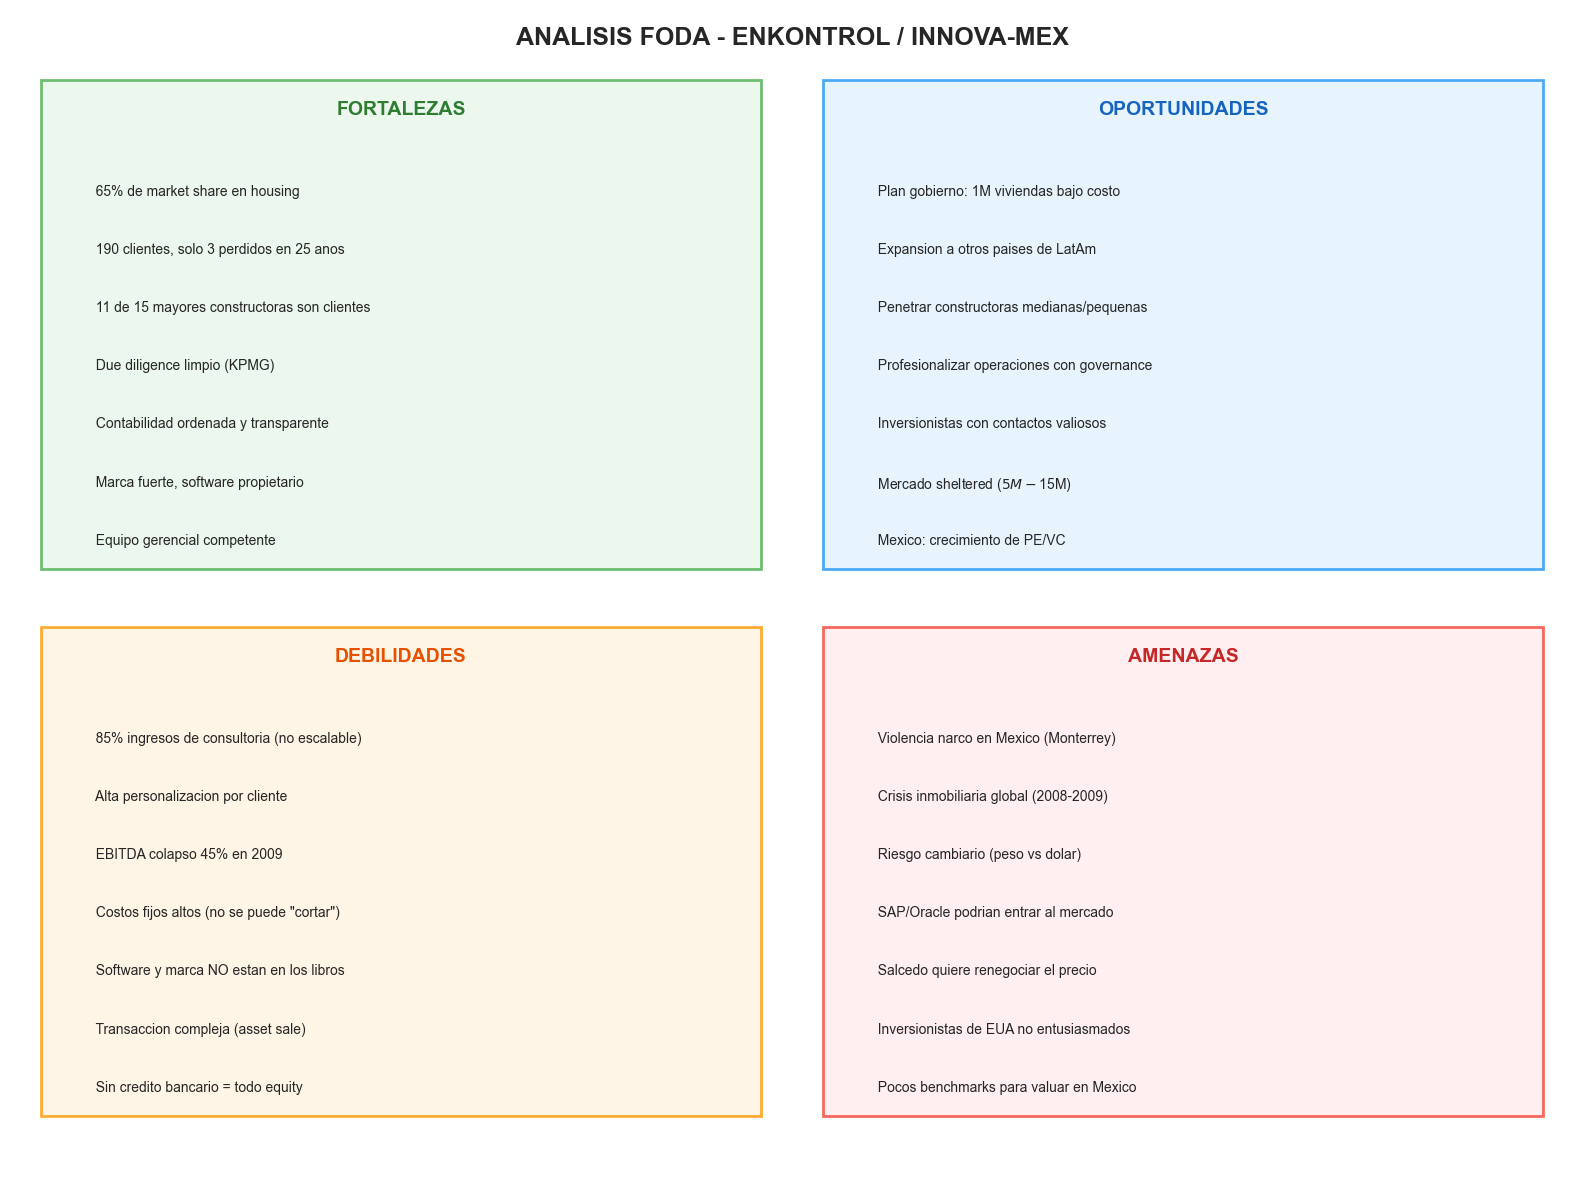

In [40]:
# ============================================================
# PASO 11: Analisis FODA (SWOT) Visual
# ============================================================

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Titulo
ax.text(5, 9.7, 'ANALISIS FODA - ENKONTROL / INNOVA-MEX', 
        ha='center', fontsize=18, fontweight='bold')

# --- FORTALEZAS (arriba izquierda) ---
rect1 = plt.Rectangle((0.2, 5.2), 4.6, 4.2, linewidth=2, 
                       edgecolor='#4CAF50', facecolor='#E8F5E9', alpha=0.8)
ax.add_patch(rect1)
ax.text(2.5, 9.1, 'FORTALEZAS', ha='center', fontsize=14, fontweight='bold', color='#2E7D32')
fortalezas = [
    '65% de market share en housing',
    '190 clientes, solo 3 perdidos en 25 anos',
    '11 de 15 mayores constructoras son clientes',
    'Due diligence limpio (KPMG)',
    'Contabilidad ordenada y transparente',
    'Marca fuerte, software propietario',
    'Equipo gerencial competente'
]
for i, f in enumerate(fortalezas):
    ax.text(0.5, 8.5 - i*0.5, f'  {f}', fontsize=10, va='top')

# --- OPORTUNIDADES (arriba derecha) ---
rect2 = plt.Rectangle((5.2, 5.2), 4.6, 4.2, linewidth=2,
                       edgecolor='#2196F3', facecolor='#E3F2FD', alpha=0.8)
ax.add_patch(rect2)
ax.text(7.5, 9.1, 'OPORTUNIDADES', ha='center', fontsize=14, fontweight='bold', color='#1565C0')
oportunidades = [
    'Plan gobierno: 1M viviendas bajo costo',
    'Expansion a otros paises de LatAm',
    'Penetrar constructoras medianas/pequenas',
    'Profesionalizar operaciones con governance',
    'Inversionistas con contactos valiosos',
    'Mercado sheltered ($5M-$15M)',
    'Mexico: crecimiento de PE/VC'
]
for i, o in enumerate(oportunidades):
    ax.text(5.5, 8.5 - i*0.5, f'  {o}', fontsize=10, va='top')

# --- DEBILIDADES (abajo izquierda) ---
rect3 = plt.Rectangle((0.2, 0.5), 4.6, 4.2, linewidth=2,
                       edgecolor='#FF9800', facecolor='#FFF3E0', alpha=0.8)
ax.add_patch(rect3)
ax.text(2.5, 4.4, 'DEBILIDADES', ha='center', fontsize=14, fontweight='bold', color='#E65100')
debilidades = [
    '85% ingresos de consultoria (no escalable)',
    'Alta personalizacion por cliente',
    'EBITDA colapso 45% en 2009',
    'Costos fijos altos (no se puede "cortar")',
    'Software y marca NO estan en los libros',
    'Transaccion compleja (asset sale)',
    'Sin credito bancario = todo equity'
]
for i, d in enumerate(debilidades):
    ax.text(0.5, 3.8 - i*0.5, f'  {d}', fontsize=10, va='top')

# --- AMENAZAS (abajo derecha) ---
rect4 = plt.Rectangle((5.2, 0.5), 4.6, 4.2, linewidth=2,
                       edgecolor='#F44336', facecolor='#FFEBEE', alpha=0.8)
ax.add_patch(rect4)
ax.text(7.5, 4.4, 'AMENAZAS', ha='center', fontsize=14, fontweight='bold', color='#C62828')
amenazas = [
    'Violencia narco en Mexico (Monterrey)',
    'Crisis inmobiliaria global (2008-2009)',
    'Riesgo cambiario (peso vs dolar)',
    'SAP/Oracle podrian entrar al mercado',
    'Salcedo quiere renegociar el precio',
    'Inversionistas de EUA no entusiasmados',
    'Pocos benchmarks para valuar en Mexico'
]
for i, a in enumerate(amenazas):
    ax.text(5.5, 3.8 - i*0.5, f'  {a}', fontsize=10, va='top')

plt.tight_layout()
plt.show()

---
## SECCION 12: La Decision Final - Framework de Negociacion

Este es el corazon del caso: **Deben aceptar la contraoferta de Salcedo o mantenerse firmes?**

Vamos a analizar los factores que pesan en cada direccion y calcular el "precio maximo" que deberian estar dispuestos a pagar.

   ANALISIS: PRECIO MAXIMO ACEPTABLE

  Para lograr 30% IRR en 5 anos:
  Los inversionistas necesitan 3.71x su inversion

  EBITDA proyectado ano 5:     $1.93M
  EV de venta (5.68x):         $10.98M
  Valor 80% INNOVA al vender:  $8.78M
  Valor presente al 30%:       $2.37M

  EV MAXIMO DE COMPRA:   $2.96M
  MULTIPLO MAXIMO:       2.5x EBITDA 2009



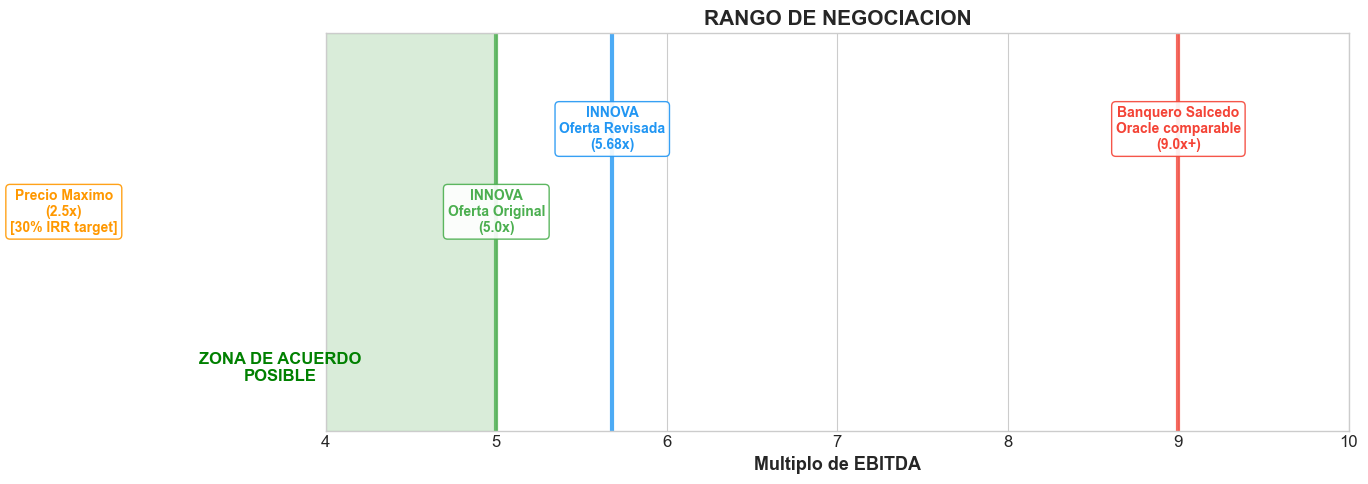


CONCLUSION DE NEGOCIACION:
- Oferta actual (5.68x) esta DENTRO del rango aceptable
- Podrian subir hasta ~2.5x y aun lograr su meta de 30% IRR
- MAS ALLA de eso, el deal deja de hacer sentido financiero
- La referencia a Oracle (9x) es inaceptable para este tipo de empresa


In [41]:
# ============================================================
# PASO 12: Analisis de Negociacion - Precio Maximo
# ============================================================
# Cuanto es lo MAXIMO que deberian pagar para que el deal funcione?
#
# Logica: Si necesitan 30% IRR en 5 anos, podemos calcular hacia atras
# cuanto pueden pagar hoy.

print("=" * 70)
print("   ANALISIS: PRECIO MAXIMO ACEPTABLE")
print("=" * 70)
print()

# Supuestos para el caso base
target_irr = 0.30  # 30% IRR objetivo
horizonte = 5
tasa_crec_ebitda = 0.10  # 10% crecimiento anual
multiplo_salida = 5.68   # Mismo multiplo de compra para ser conservador

# EBITDA proyectado al ano 5
ebitda_ano5 = ebitda_2009 * (1 + tasa_crec_ebitda) ** horizonte

# Enterprise Value al vender
ev_venta = ebitda_ano5 * multiplo_salida

# Valor del 80% de INNOVA al vender (antes de repartir con managers)
valor_80pct_venta = ev_venta * 0.80

# Para lograr 30% IRR, el valor futuro debe ser:
# Inversion * (1 + IRR)^5 = Valor_Futuro
# Inversion = Valor_Futuro / (1 + IRR)^5
# Pero hay que considerar los intereses de deuda sub que reciben cada ano

# Simplificacion: calculemos el EV maximo de compra
# Inversionistas ponen 80% del EV de compra (equity + sub debt)
# Necesitan recibir eso * (1+30%)^5 = 3.71x su inversion

factor_retorno = (1 + target_irr) ** horizonte
print(f"  Para lograr {target_irr*100:.0f}% IRR en {horizonte} anos:")
print(f"  Los inversionistas necesitan {factor_retorno:.2f}x su inversion")
print()

# Valor presente del 80% del EV de venta
# descontado al 30%
vp_equity = valor_80pct_venta / factor_retorno

# Sumar valor presente de intereses de deuda subordinada
# (14% anual sobre el 20% del monto financiado por INNOVA)
# Esto reduce un poco lo que necesitan de la venta
print(f"  EBITDA proyectado ano 5:     ${ebitda_ano5:.2f}M")
print(f"  EV de venta (5.68x):         ${ev_venta:.2f}M")
print(f"  Valor 80% INNOVA al vender:  ${valor_80pct_venta:.2f}M")
print(f"  Valor presente al 30%:       ${vp_equity:.2f}M")
print()

# EV maximo de compra
ev_max_compra = vp_equity / 0.80  # INNOVA compra 80%
multiplo_max = ev_max_compra / ebitda_2009

print(f"  ====================================")
print(f"  EV MAXIMO DE COMPRA:   ${ev_max_compra:.2f}M")
print(f"  MULTIPLO MAXIMO:       {multiplo_max:.1f}x EBITDA 2009")
print(f"  ====================================")
print()

# --- GRAFICO: Rango de negociacion ---
fig, ax = plt.subplots(figsize=(14, 5))

# Rango visual
rangos = {
    'INNOVA\nOferta Original\n(5.0x)': 5.0,
    'INNOVA\nOferta Revisada\n(5.68x)': 5.68,
    f'Precio Maximo\n({multiplo_max:.1f}x)\n[30% IRR target]': multiplo_max,
    'Banquero Salcedo\nOracle comparable\n(9.0x+)': 9.0
}

colores_r = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
posiciones = list(rangos.values())
etiquetas_r = list(rangos.keys())

for i, (pos, color, etiqueta) in enumerate(zip(posiciones, colores_r, etiquetas_r)):
    ax.axvline(x=pos, color=color, linewidth=3, alpha=0.8)
    ax.text(pos, 0.6 + (i % 2) * 0.25, etiqueta, ha='center', fontsize=10, 
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9))

# Zona de acuerdo posible (ZOPA)
ax.axvspan(5.0, multiplo_max, alpha=0.15, color='green')
ax.text((5.0 + multiplo_max)/2, 0.15, 'ZONA DE ACUERDO\nPOSIBLE', 
        ha='center', fontsize=12, fontweight='bold', color='green')

ax.set_xlim(4, 10)
ax.set_ylim(0, 1.2)
ax.set_xlabel('Multiplo de EBITDA', fontweight='bold', fontsize=13)
ax.set_title('RANGO DE NEGOCIACION', fontweight='bold', fontsize=15)
ax.set_yticks([])

plt.tight_layout()
plt.show()

print("\nCONCLUSION DE NEGOCIACION:")
print(f"- Oferta actual (5.68x) esta DENTRO del rango aceptable")
print(f"- Podrian subir hasta ~{multiplo_max:.1f}x y aun lograr su meta de 30% IRR")
print(f"- MAS ALLA de eso, el deal deja de hacer sentido financiero")
print(f"- La referencia a Oracle (9x) es inaceptable para este tipo de empresa")

---
## SECCION 13: Resumen Ejecutivo y Preguntas de Discusion

Este es el cierre del analisis. Aqui se resumen los hallazgos clave y las preguntas que deberias poder responder en clase.

In [42]:
# ============================================================
# PASO 13: Resumen Ejecutivo Final
# ============================================================

print("=" * 70)
print("   RESUMEN EJECUTIVO: INNOVA-MEX / ENKONTROL")
print("=" * 70)
print()
print("1. EL NEGOCIO:")
print("   ENKONTROL es el ERP lider para construccion en Mexico")
print("   con 65% de market share y 190 clientes. Solo ha perdido")
print("   3 clientes en 25 anos. Contabilidad limpia (KPMG).")
print()
print("2. EL PROBLEMA:")
print("   El EBITDA cayo fuertemente en 2009 (-24% ingresos).")
print("   85% del ingreso viene de consultoria (no escalable).")
print("   No hay deuda bancaria disponible en Mexico.")
print()
print("3. EL DEAL:")
print("   INNOVA compra 80% a 5.68x EBITDA 2009.")
print("   Financiado: 60% equity + 20% deuda sub + 20% seller note.")
print("   Salcedo retiene 20% y se queda en el board.")
print()
print("4. LOS NUMEROS:")
print(f"   Enterprise Value:  ~${ev_compra:.1f}M USD")
print(f"   Target IRR:        30% anual")
print(f"   Para lograrlo:     Necesitan >10% crec. anual + multiplo salida >5x")
print()
print("5. RIESGOS PRINCIPALES:")
print("   - Tipo de cambio (inversionistas quieren retornos en USD)")
print("   - Modelo de negocio basado en horas (no escalable)")
print("   - Sector construccion vulnerable a ciclos economicos")
print("   - Complejidad de la transaccion (asset sale)")
print()
print("6. LA DECISION:")
print("   Deberian CERRAR el deal a 5.68x. Es un precio razonable")
print("   dentro de su rango aceptable. Si Salcedo pide mas,")
print("   pueden subir ligeramente pero NO acercarse a 9x.")
print()
print("=" * 70)
print("   PREGUNTAS CLAVE PARA DISCUSION EN CLASE")
print("=" * 70)
print()
print("   Q1: Deberian cerrar el deal? A que precio maximo?")
print()
print("   Q2: Es ENKONTROL realmente 'unbreakable'?")
print("       (Recuerda: los search funds buscan negocios 'irrompibles')")
print()
print("   Q3: Como cambia el modelo de search fund en mercados")
print("       emergentes vs EUA?")
print()
print("   Q4: La divergencia entre inversionistas mexicanos (a favor)")
print("       y estadounidenses (en contra) - quien tiene razon?")
print()
print("   Q5: Que palancas de crecimiento tienen para mejorar")
print("       el negocio post-adquisicion?")
print()
print("   Q6: El riesgo cambiario es suficientemente significativo")
print("       como para matar los retornos?")
print()
print("=" * 70)
print("   FIN DEL ANALISIS - Comparte los resultados conmigo!")
print("=" * 70)

   RESUMEN EJECUTIVO: INNOVA-MEX / ENKONTROL

1. EL NEGOCIO:
   ENKONTROL es el ERP lider para construccion en Mexico
   con 65% de market share y 190 clientes. Solo ha perdido
   3 clientes en 25 anos. Contabilidad limpia (KPMG).

2. EL PROBLEMA:
   El EBITDA cayo fuertemente en 2009 (-24% ingresos).
   85% del ingreso viene de consultoria (no escalable).
   No hay deuda bancaria disponible en Mexico.

3. EL DEAL:
   INNOVA compra 80% a 5.68x EBITDA 2009.
   Financiado: 60% equity + 20% deuda sub + 20% seller note.
   Salcedo retiene 20% y se queda en el board.

4. LOS NUMEROS:
   Enterprise Value:  ~$6.8M USD
   Target IRR:        30% anual
   Para lograrlo:     Necesitan >10% crec. anual + multiplo salida >5x

5. RIESGOS PRINCIPALES:
   - Tipo de cambio (inversionistas quieren retornos en USD)
   - Modelo de negocio basado en horas (no escalable)
   - Sector construccion vulnerable a ciclos economicos
   - Complejidad de la transaccion (asset sale)

6. LA DECISION:
   Deberian CERRA